# Studying GH-AW Histories

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pavt/GHAW-H/blob/main/notebooks/history_data.ipynb)

This notebook illustrates the research potential unlocked by publishing **file-version histories**, not only repository-level snapshots.

It uses only public release tables under `data/*.parquet`, with the local release mirror acting like a Hugging Face dataset snapshot.


In [1]:
from __future__ import annotations

import importlib.util
import subprocess
import sys
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "pyarrow": "pyarrow",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

if "google.colab" in sys.modules:
    missing = [
        package
        for package, import_name in REQUIRED_PACKAGES.items()
        if importlib.util.find_spec(import_name) is None
    ]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

DATASET_ID = "pavtch/GHAW-H"
DATASET_REVISION = "main"
LOCAL_RELEASE_CANDIDATES = [
    Path(".."),
    Path("."),
    Path("../releases/gh-aw-early-adopters-source-history-2026-06-26"),
    Path("releases/gh-aw-early-adopters-source-history-2026-06-26"),
    Path("../releases/gawd"),
    Path("releases/gawd"),
]
LOCAL_RELEASE_MIRROR = next(
    (
        path.resolve()
        for path in LOCAL_RELEASE_CANDIDATES
        if (path / "data").is_dir() and any((path / "data").glob("*.parquet"))
    ),
    None,
)
USE_LOCAL_MIRROR = "google.colab" not in sys.modules and LOCAL_RELEASE_MIRROR is not None


def remote_parquet_url(table_name: str) -> str:
    return (
        f"https://huggingface.co/datasets/{DATASET_ID}/resolve/"
        f"{DATASET_REVISION}/data/{table_name}.parquet"
    )


def local_parquet_path(table_name: str) -> Path:
    if LOCAL_RELEASE_MIRROR is None:
        raise FileNotFoundError("No local release mirror with a data/ directory was found.")
    return LOCAL_RELEASE_MIRROR / "data" / f"{table_name}.parquet"


def parquet_path(table_name: str) -> str:
    if USE_LOCAL_MIRROR:
        return str(local_parquet_path(table_name))
    return remote_parquet_url(table_name)


def read_parquet_table(table_name: str) -> pd.DataFrame:
    if USE_LOCAL_MIRROR:
        return pd.read_parquet(local_parquet_path(table_name))

    try:
        with urlopen(remote_parquet_url(table_name)) as response:
            return pd.read_parquet(BytesIO(response.read()))
    except Exception:
        if LOCAL_RELEASE_MIRROR is not None:
            return pd.read_parquet(local_parquet_path(table_name))
        raise

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.0,
        "axes.labelsize": 14,
        "axes.titlesize": 15,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "legend.title_fontsize": 11,
        "figure.dpi": 160,
    }
)
sns.set_style("whitegrid")

NOTEBOOK_DIR = Path("data_analysis") if Path("data_analysis").is_dir() else Path(".")
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_and_show(fig: plt.Figure, out: Path) -> None:
    png_out = out.with_suffix(".png")
    pdf_out = out.with_suffix(".pdf")
    fig.savefig(png_out, bbox_inches="tight", dpi=300)
    fig.savefig(pdf_out, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(png_out)))
    print("Wrote", png_out)
    print("Wrote", pdf_out)


In [2]:
# ----------------------- Load and shape histories -----------------------
repository_df = read_parquet_table("repository")
history_df = read_parquet_table("source_markdown_file_history")
snapshot_df = read_parquet_table("source_markdown_file_snapshot")
version_df = read_parquet_table("source_markdown_file_version")
lock_snapshot_df = read_parquet_table("lock_file_snapshot")

events_df = (
    version_df.merge(
        snapshot_df,
        on="source_markdown_file_snapshot_id",
        how="inner",
        validate="many_to_one",
    )
    .merge(repository_df, on="repository_id", how="left", validate="many_to_one")
    .merge(
        lock_snapshot_df[["source_markdown_file_version_id", "lock_file_snapshot_id"]],
        on="source_markdown_file_version_id",
        how="left",
        validate="one_to_one",
    )
)
events_df["committed_at"] = pd.to_datetime(events_df["committed_at"], utc=True, errors="coerce")
events_df = events_df.dropna(subset=["committed_at"]).copy()
events_df["committed_month"] = (
    events_df["committed_at"].dt.tz_convert(None).dt.to_period("M").dt.to_timestamp()
)
events_df = events_df.sort_values([
    "repository_id",
    "source_markdown_file_history_id",
    "committed_at",
    "rank",
])

history_summary_df = (
    events_df.groupby(["repository_id", "source_markdown_file_history_id"], as_index=False)
    .agg(
        repo_full_name=("repo_full_name", "first"),
        main_language=("main_language", "first"),
        history_versions=("source_markdown_file_version_id", "count"),
        first_version_at=("committed_at", "min"),
        last_version_at=("committed_at", "max"),
        source_paths=("path", "nunique"),
        lock_snapshots=("lock_file_snapshot_id", "count"),
    )
)
history_summary_df["history_span_days"] = (
    history_summary_df["last_version_at"] - history_summary_df["first_version_at"]
).dt.total_seconds() / 86400

repo_history_df = (
    history_summary_df.groupby("repository_id", as_index=False)
    .agg(
        repo_full_name=("repo_full_name", "first"),
        main_language=("main_language", "first"),
        histories=("source_markdown_file_history_id", "count"),
        observed_versions=("history_versions", "sum"),
        max_versions_in_one_history=("history_versions", "max"),
        first_observed_at=("first_version_at", "min"),
        last_observed_at=("last_version_at", "max"),
    )
)
repo_history_df["repo_history_span_days"] = (
    repo_history_df["last_observed_at"] - repo_history_df["first_observed_at"]
).dt.total_seconds() / 86400

history_summary_df.head()


,repository_id,source_markdown_file_history_id,repo_full_name,main_language,history_versions,first_version_at,last_version_at,source_paths,lock_snapshots,history_span_days
0,71596680617275803,310,KunalSin9h/meltcd,Go,2,2026-02-26 18:19:47+00:00,2026-02-26 18:28:02+00:00,1,2,0.005729
1,71596680617275803,311,KunalSin9h/meltcd,Go,2,2026-02-27 06:20:44+00:00,2026-02-27 06:34:23+00:00,1,2,0.009479
2,71596680617275803,312,KunalSin9h/meltcd,Go,4,2026-02-26 18:45:35+00:00,2026-02-27 06:20:44+00:00,1,4,0.482743
3,105955057410921839,565,inference-sh/shadcn-registry,TypeScript,2,2026-05-19 08:11:17+00:00,2026-05-19 08:13:55+00:00,1,2,0.001829
4,115152077126393147,568,microsoft/physical-ai-toolchain,Python,11,2026-04-20 16:15:27+00:00,2026-06-23 07:26:13+00:00,1,11,63.632477


In [3]:
# ----------------------- What histories add -----------------------
history_value_summary = pd.DataFrame(
    [
        {"metric": "repositories", "value": repository_df["repository_id"].nunique()},
        {"metric": "source histories", "value": history_summary_df["source_markdown_file_history_id"].nunique()},
        {"metric": "source versions", "value": events_df["source_markdown_file_version_id"].nunique()},
        {"metric": "lock snapshots", "value": events_df["lock_file_snapshot_id"].notna().sum()},
        {"metric": "median versions per repository", "value": repo_history_df["observed_versions"].median()},
        {"metric": "max versions in one repository", "value": repo_history_df["observed_versions"].max()},
        {"metric": "median history span days", "value": history_summary_df["history_span_days"].median()},
        {"metric": "max repository history span days", "value": repo_history_df["repo_history_span_days"].max()},
    ]
)
history_value_summary


,metric,value
0,repositories,262.000000
1,source histories,604.000000
2,source versions,2820.000000
3,lock snapshots,2820.000000
4,median versions per repository,3.000000
5,max versions in one repository,205.000000
6,median history span days,7.001458
7,max repository history span days,246.479792


Wrote data_analysis/figs/gawd_history_depth.png
Wrote data_analysis/figs/gawd_history_depth.pdf


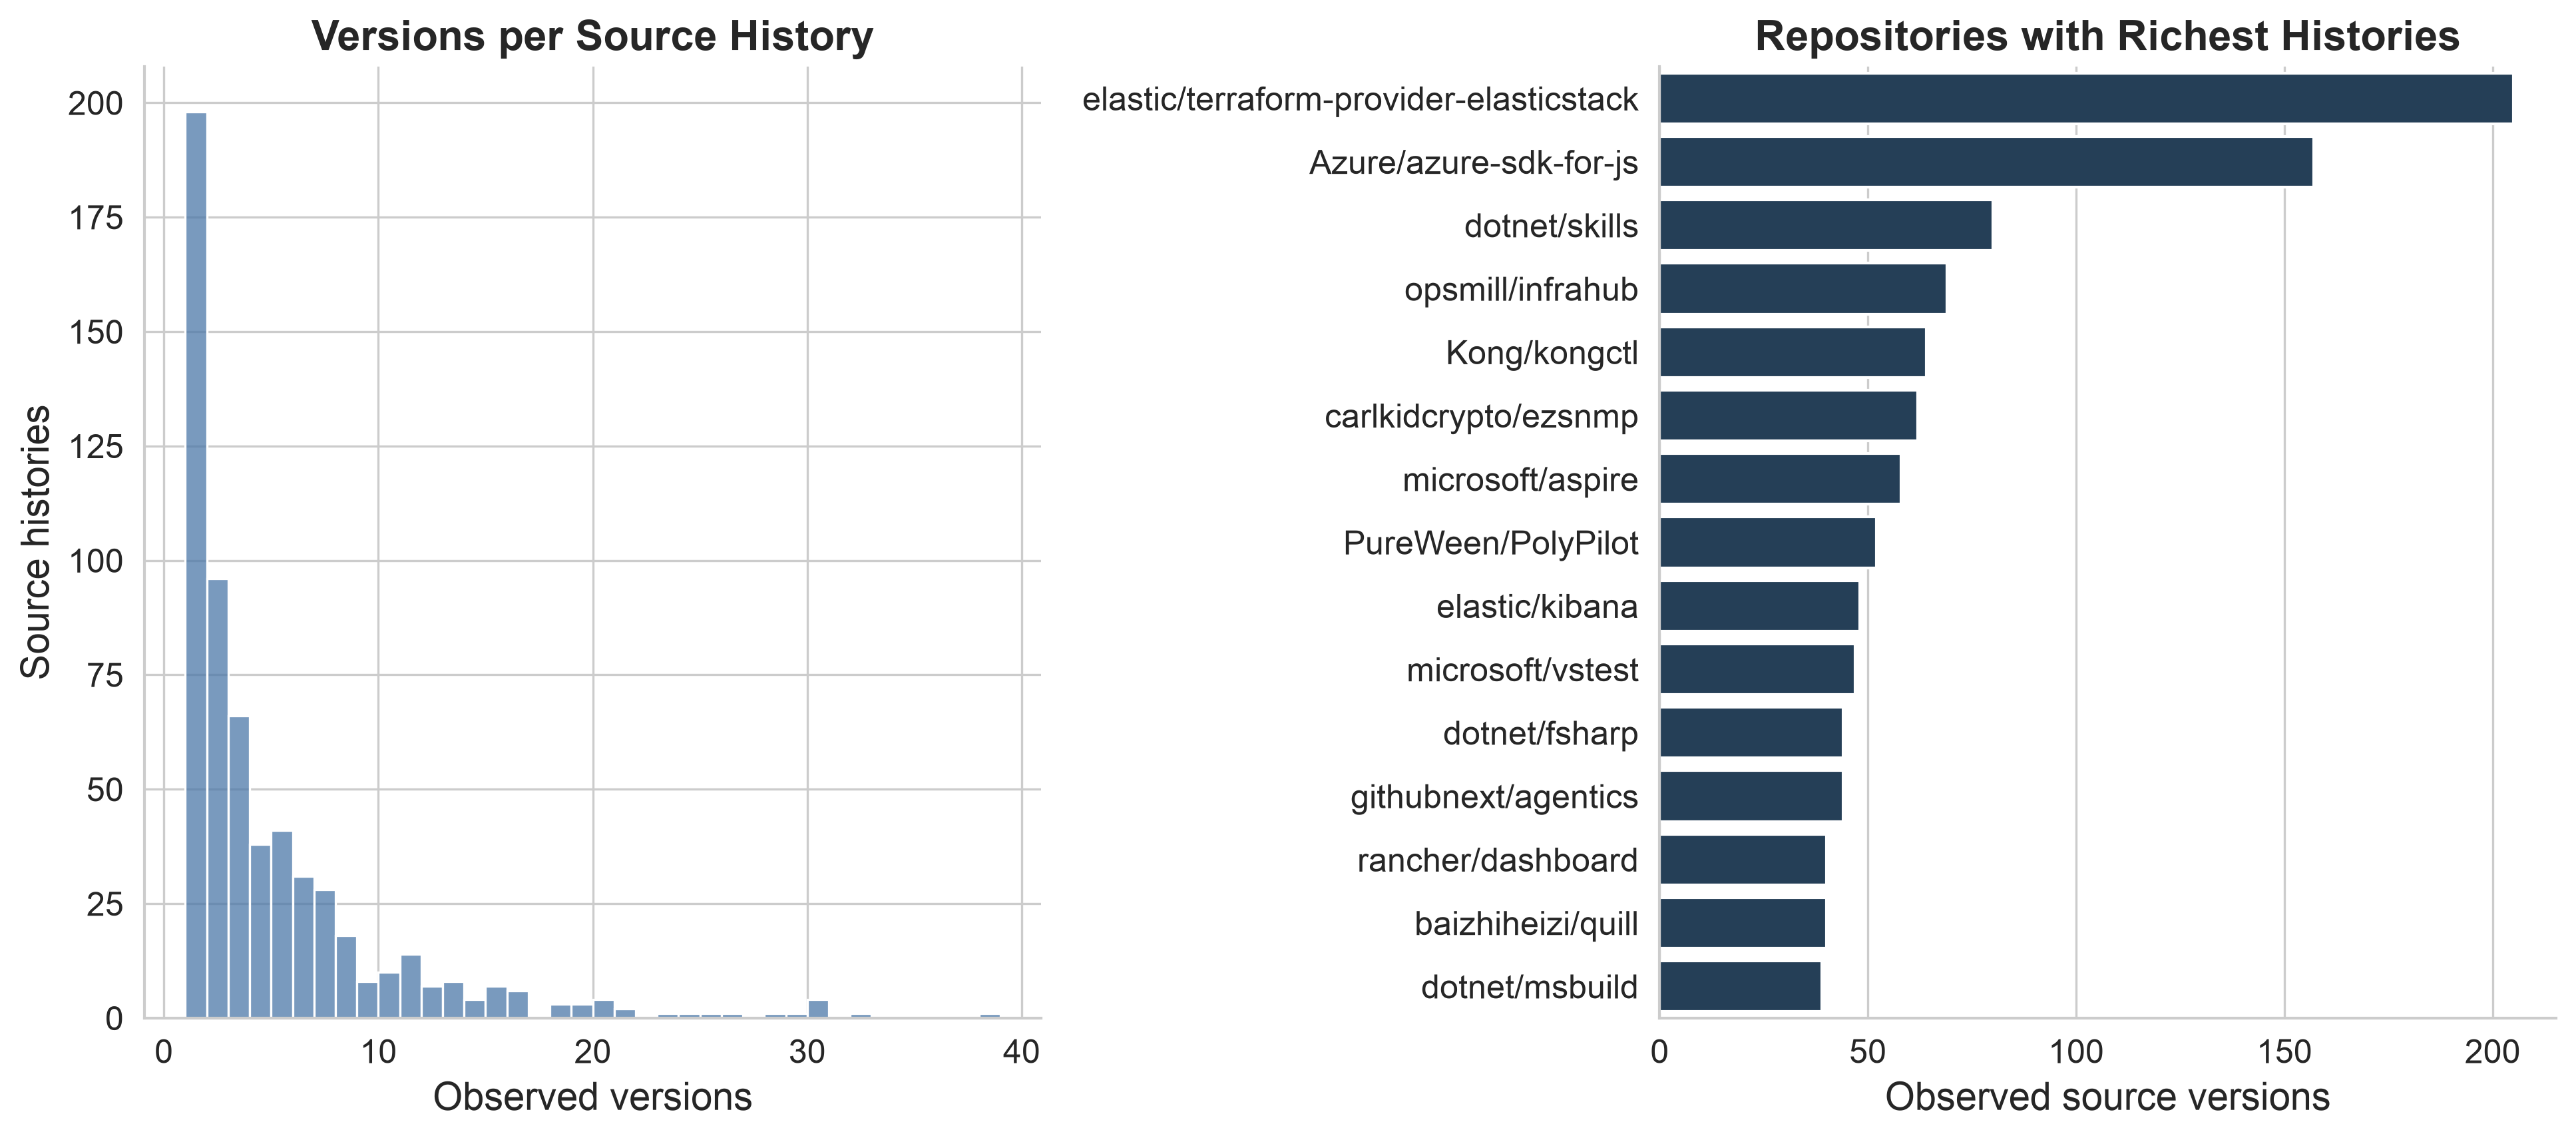

In [4]:
# ----------------------- Figure 1: depth of histories -----------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))

sns.histplot(
    data=history_summary_df,
    x="history_versions",
    bins=range(1, int(history_summary_df["history_versions"].max()) + 2),
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Versions per Source History", weight="bold")
axes[0].set_xlabel("Observed versions")
axes[0].set_ylabel("Source histories")

top_repos = repo_history_df.sort_values("observed_versions", ascending=False).head(15)
sns.barplot(
    data=top_repos,
    y="repo_full_name",
    x="observed_versions",
    color="#1C3F60",
    ax=axes[1],
)
axes[1].set_title("Repositories with Richest Histories", weight="bold")
axes[1].set_xlabel("Observed source versions")
axes[1].set_ylabel(None)

sns.despine(fig=fig)
fig.tight_layout()
out = FIG_DIR / "gawd_history_depth.png"
save_and_show(fig, out)


Wrote data_analysis/figs/gawd_history_span_vs_versions.png
Wrote data_analysis/figs/gawd_history_span_vs_versions.pdf


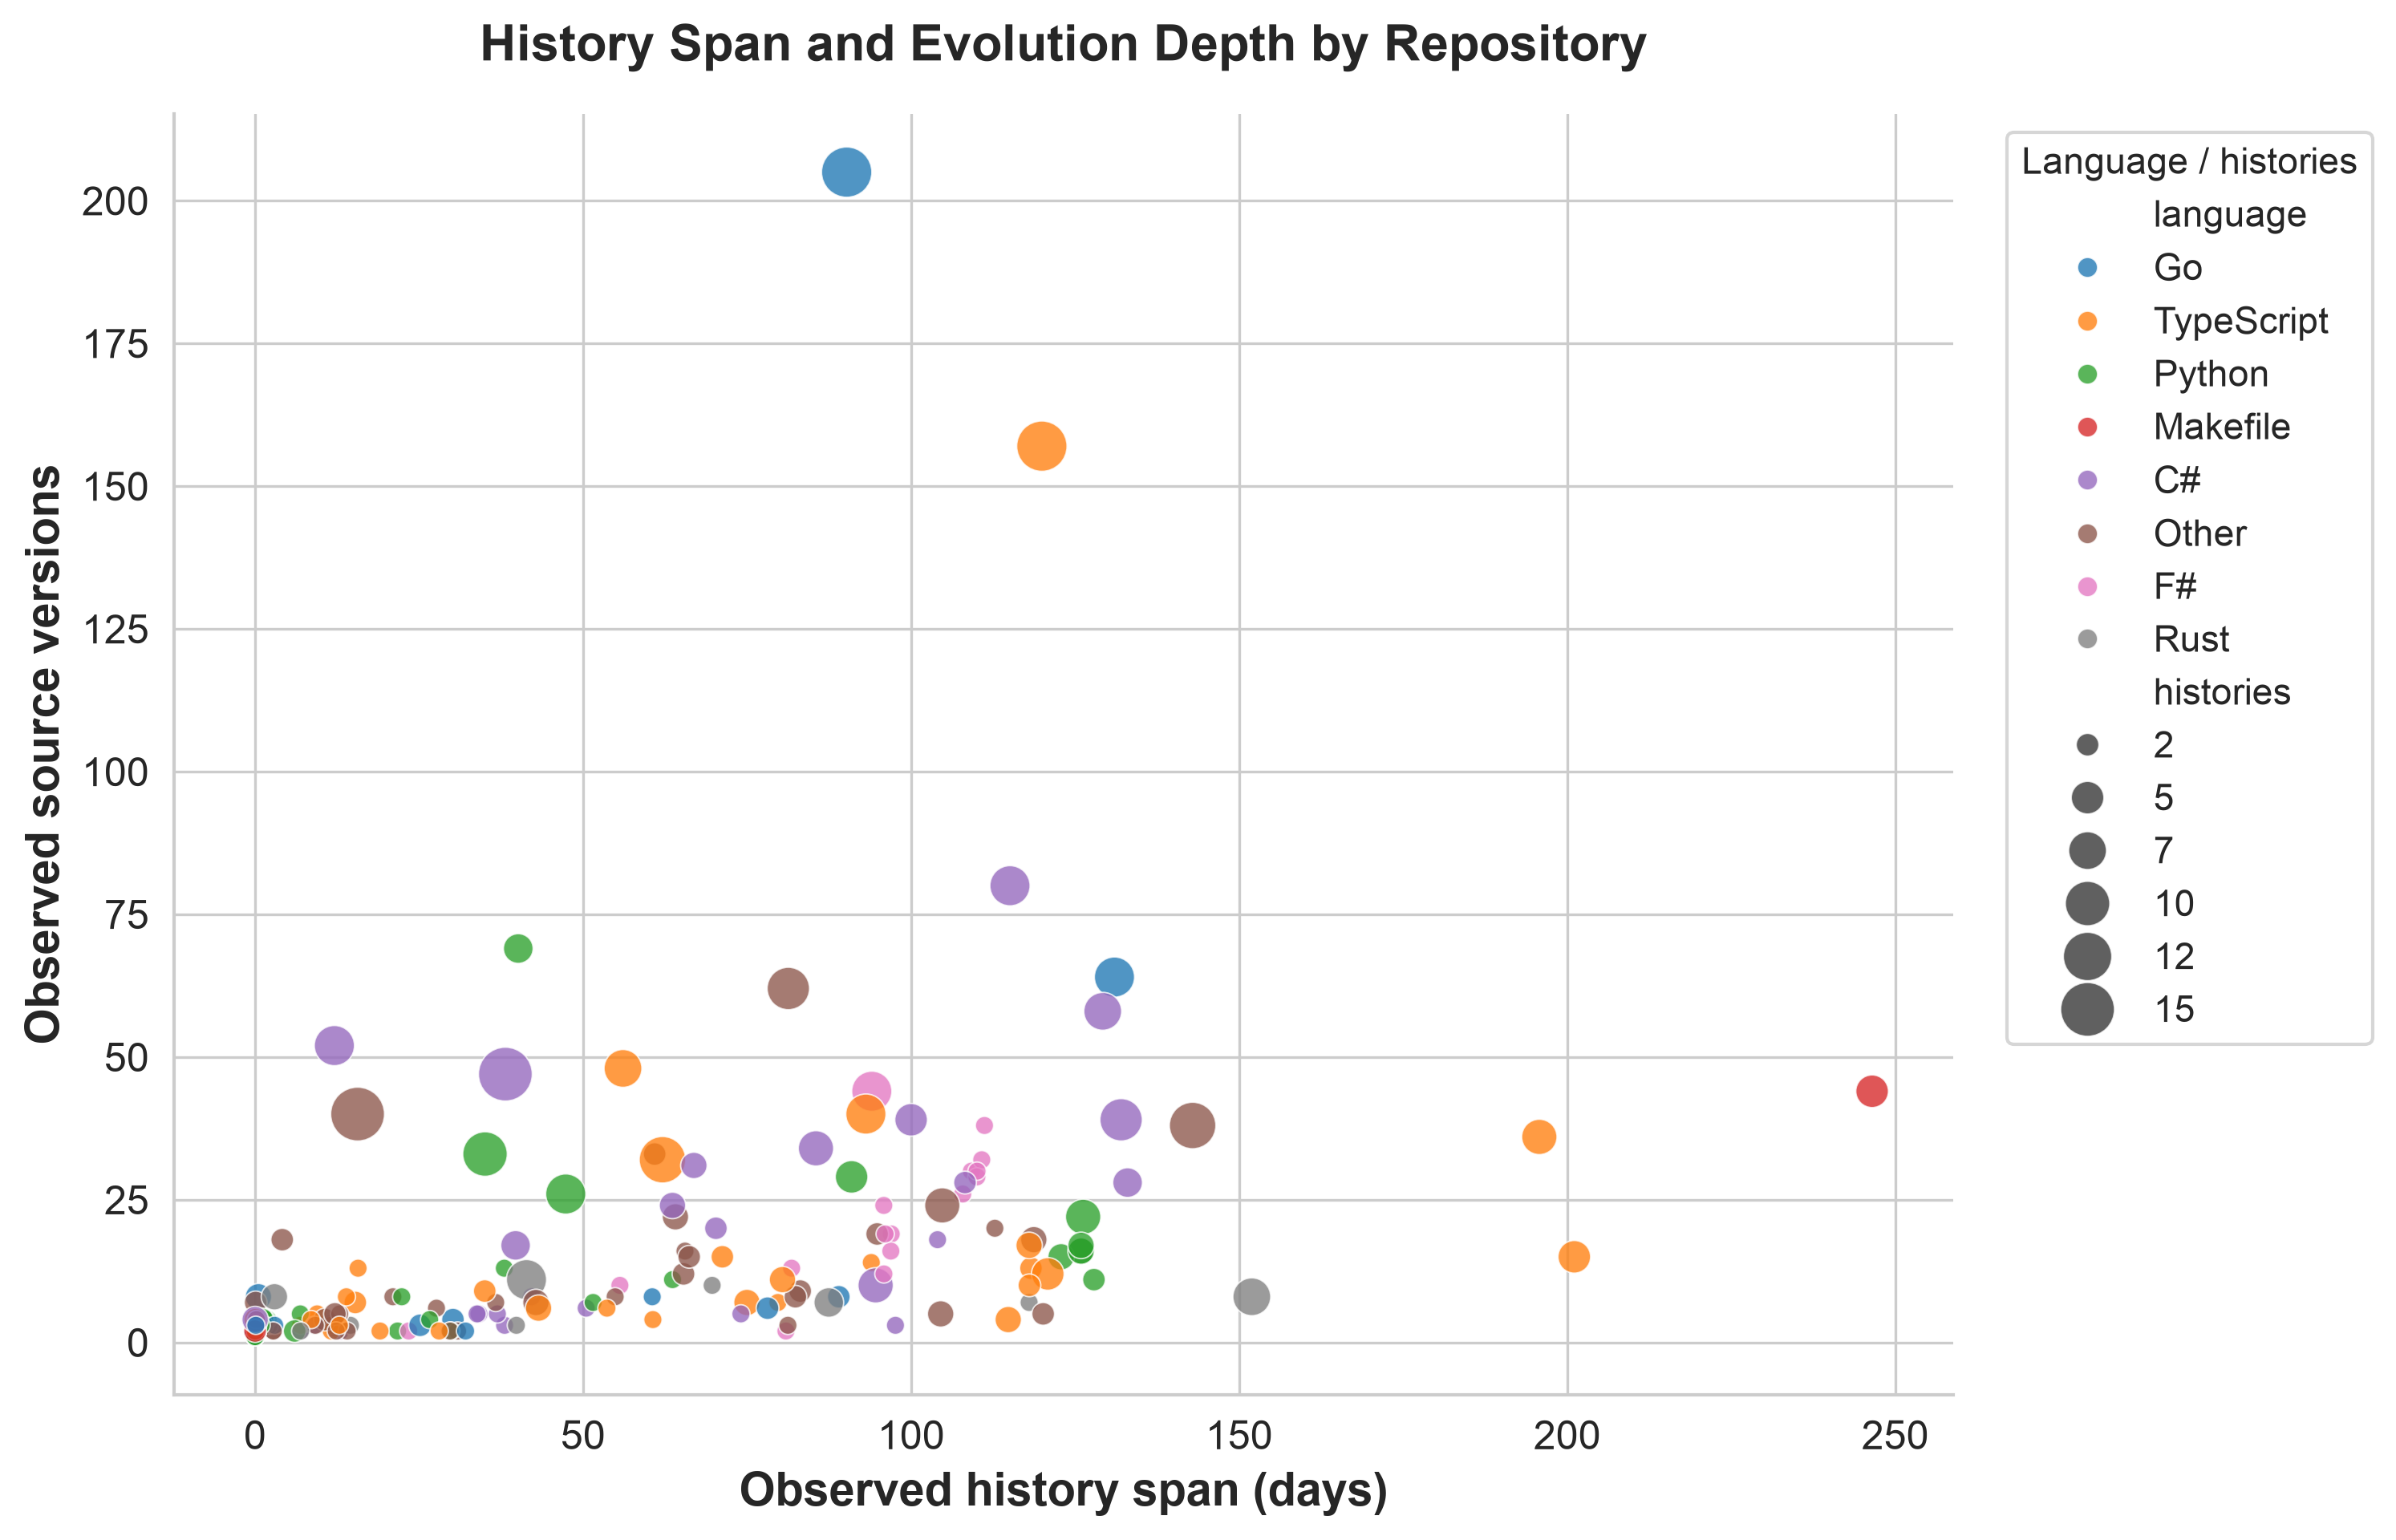

In [5]:
# ----------------------- Figure 2: temporal span vs number of versions -----------------------
plot_repo = repo_history_df.copy()
plot_repo["language"] = plot_repo["main_language"].fillna("Unknown")
top_languages = plot_repo["language"].value_counts().head(7).index
plot_repo["language"] = plot_repo["language"].where(plot_repo["language"].isin(top_languages), "Other")

fig, ax = plt.subplots(figsize=(10, 6.5))
sns.scatterplot(
    data=plot_repo,
    x="repo_history_span_days",
    y="observed_versions",
    hue="language",
    size="histories",
    sizes=(30, 260),
    alpha=0.78,
    palette="tab10",
    ax=ax,
)
ax.set_title("History Span and Evolution Depth by Repository", pad=16, weight="bold")
ax.set_xlabel("Observed history span (days)", fontweight="bold")
ax.set_ylabel("Observed source versions", fontweight="bold")
ax.legend(title="Language / histories", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine(ax=ax)
fig.tight_layout()
out = FIG_DIR / "gawd_history_span_vs_versions.png"
save_and_show(fig, out)
